In [ ]:
# Mounting Drive & installing necessary updates

from google.colab import drive
from pathlib import Path
import os

# Mounting Google Drive
drive.mount('/content/drive')

PROJECT_DIR = Path("/content/drive/MyDrive/NLP_Research_Project")
OUT_DIR     = PROJECT_DIR / "outputs"
DATA_DIR    = PROJECT_DIR / "data"          # (Optional if you still use this)
FINAL_DS_DIR = OUT_DIR / "Final Datasets "   # <--- YOUR NEW FOLDER

print(f"📂 Project Dir: {PROJECT_DIR}")
print(f"📂 Outputs Dir: {OUT_DIR}")
print(f"📂 Final Datasets Dir: {FINAL_DS_DIR}")


# Installing necessary Libraries
!pip -q install pandas numpy scikit-learn nltk matplotlib seaborn tqdm openai anthropic transformers datasets evaluate

print("\n Drive Mounted & Libraries Installed.")

Mounted at /content/drive
📂 Project Dir: /content/drive/MyDrive/NLP_Research_Project
📂 Outputs Dir: /content/drive/MyDrive/NLP_Research_Project/outputs
📂 Final Datasets Dir: /content/drive/MyDrive/NLP_Research_Project/outputs/Final Datasets 
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.5/837.5 kB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 11.0 MB/s eta 0:00:00

✅ Drive Mounted & Libraries Installed.
⚠️ IF YOU HAVEN'T RESTARTED RUNTIME YET, DO IT NOW (Runtime > Restart Session).


In [ ]:
# Configuration & API keys

import pandas as pd
import numpy as np
import os
import time
import json
import re
from collections import Counter
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from openai import OpenAI
import anthropic

# API Keys (OpenAI and Claude)
OPENAI_KEY = "YOUR_OPENAI_API_KEY"
CLAUDE_KEY = "YOUR_CLAUDE_API_KEY"

# Setup Clients
client_openai = OpenAI(api_key=OPENAI_KEY)
client_claude = anthropic.Anthropic(api_key=CLAUDE_KEY)

#model configuration
MODELS = {
    "GPT4o": "gpt-4o",
    "GPT4oMini": "gpt-4o-mini",


    "ClaudeSonnet": "claude-sonnet-4-6",
    "ClaudeOpus": "claude-opus-4-6"
}

STANCE_LABELS = ["Positive", "Negative", "Neutral", "Mixed"]

ALLOWED_TOPICS = [
    "Anxiety", "Depression", "Suicide/Self-Harm",
    "Bullying/Cyberbullying", "Body Image/Eating Disorders",
    "Addiction/Overuse", "Sleep Disruption",
    "Policy/Lawsuits/Bans", "School/Education",
    "Therapy/Access to Care", "Stigma/Awareness",
    "Parental Controls/Safety Features"
]

print(f" Configuration Loaded. Using Models: {list(MODELS.values())}")

✅ Configuration Loaded. Using Models: ['gpt-4o', 'gpt-4o-mini', 'claude-sonnet-4-6', 'claude-opus-4-6']


In [ ]:
# Data Merging & Preparation

import pandas as pd

def prepare_master_dataset():
    print("--- PREPARING DATASET FROM DRIVE ---")

    path_accepted = FINAL_DS_DIR / "accepted_labelled_dataset.csv"
    path_review  = FINAL_DS_DIR / "review_stance_queue_doccano.csv"
    path_cleaned = FINAL_DS_DIR / "cleaned_relevant_only.csv"

    # Loading Gold Standard
    if path_accepted.exists():
        df_done = pd.read_csv(path_accepted)
        print(f" Loaded {len(df_done)} Accepted Labelled articles.")
    else:
        df_done = pd.DataFrame()
        print(f" Accepted Labelled Dataset file not found at: {path_accepted}")

    # Loading New Inputs
    inputs = []

    # Input A for Manual Review Queue
    if path_review.exists():
        df_rev = pd.read_csv(path_review)
        inputs.append(df_rev)
        print(f" Loaded {len(df_rev)} articles from Review Queue.")
    else:
        print(f" Review Queue not found at: {path_review}")

    # Input B for Cleaned Relevant Data
    if path_cleaned.exists():
        df_rel = pd.read_csv(path_cleaned)

        df_rel.rename(columns={'text': 'full_text'}, inplace=True)

        inputs.append(df_rel)
        print(f" Loaded {len(df_rel)} articles from Cleaned Data.")
    else:
        print(f" Cleaned Data not found at: {path_cleaned}")

    if not inputs:
        print("\n No input files found in Drive folder! Check paths.")
        return df_done, pd.DataFrame()

    # Merging Inputs
    df_queue = pd.concat(inputs, ignore_index=True)

    # Ensuring that cols exist
    for col in ['title', 'full_text', 'platform', 'doc_id']:
        if col not in df_queue.columns: df_queue[col] = ""

    # Removing Exact Duplicates
    df_queue = df_queue.drop_duplicates()

    # Filtering out already processed items
    if not df_done.empty and 'doc_id' in df_done.columns:
        done_ids = set(df_done['doc_id'].astype(str).unique())
        before_cnt = len(df_queue)
        df_queue = df_queue[~df_queue['doc_id'].astype(str).isin(done_ids)]
        print(f" (Skipped {before_cnt - len(df_queue)} articles already in Accepted Labeled Dataset)")

    print(f"\n Total Articles to process: {len(df_queue)}")
    return df_done, df_queue

df_final_done, df_processing_queue = prepare_master_dataset()

--- PREPARING DATASET FROM DRIVE ---
✅ Loaded 932 Accepted Labelled articles.
✅ Loaded 342 articles from Review Queue.
✅ Loaded 220 articles from Cleaned Data.
   (Skipped 0 articles already in Accepted Labeled Dataset)

🚀 TOTAL ARTICLES TO PROCESS: 562


In [ ]:

# Prompts & LLM Functions

STANCE_PROMPT = f"""
You are a research annotator analyzing news coverage of social media.

TASK 1: Determine the STANCE regarding the platform's impact on mental health.
- Positive: Benefits, support, community, helpful features.
- Negative: Harms, addiction, bullying, lawsuits, decline in well-being.
- Neutral: Factual business news or balanced reporting.
- Mixed: Significant elements of both harm and benefit.

TASK 2: Identify the PRIMARY TOPICS discussed in relation to mental health.
Choose up to 3 most relevant tags from this list:
{ALLOWED_TOPICS}

OUTPUT FORMAT:
Return ONLY a valid JSON object:
{{
  "label": "Positive/Negative/Neutral/Mixed",
  "topics": ["Topic 1", "Topic 2"],
  "reason": "Short explanation under 15 words"
}}
"""

def call_openai(model_name, text):
    try:
        response = client_openai.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": STANCE_PROMPT + f"\n\nARTICLE:\n{text[:6000]}"}],
            temperature=0.0,
            response_format={"type": "json_object"}
        )
        data = json.loads(response.choices[0].message.content)
        return data.get("label", "Error").strip().title(), data.get("topics", [])
    except:
        return "Error", []

def call_claude(model_name, text):
    try:
        response = client_claude.messages.create(
            model=model_name,
            max_tokens=200,
            temperature=0.0,
            messages=[{"role": "user", "content": STANCE_PROMPT + f"\n\nARTICLE:\n{text[:6000]}"}]
        )
        content = response.content[0].text.strip()

        # Clean markdown codeblocks if Claude includes them
        if content.startswith("```json"):
            content = content[7:-3].strip()
        elif content.startswith("```"):
            content = content[3:-3].strip()

        data = json.loads(content)
        return data.get("label", "Error").strip().title(), data.get("topics", [])
    except Exception as e:
        print(f" Error on {model_name}: {e}")
        return "Error", []

print(" Prompt & Functions Ready.")

✅ Prompt & Functions Ready.


In [ ]:
'''
# Execution Loop

new_data = []
print(f" Processing {len(df_processing_queue)} Articles. Please Wait!")

# Define Save Path in Drive (Updated for Claude)
partial_save_path = OUT_DIR / "partial_results_quad_claude.csv"

for idx, row in tqdm(df_processing_queue.iterrows(), total=len(df_processing_queue)):
    text = str(row['full_text'])

    # 1. Gather Votes
    v_gpt4, t_gpt4 = call_openai(MODELS['GPT4o'], text)
    v_mini, t_mini = call_openai(MODELS['GPT4oMini'], text)
    time.sleep(0.2)

    v_claude_sonnet, t_claude_sonnet = call_claude(MODELS['ClaudeSonnet'], text)
    v_claude_opus, t_claude_opus = call_claude(MODELS['ClaudeOpus'], text)
    time.sleep(0.5)

    # 2. Consensus Logic (Updated vote variables)
    valid_votes = [v for v in [v_gpt4, v_mini, v_claude_sonnet, v_claude_opus] if v in STANCE_LABELS]
    status = "No_Consensus"

    if valid_votes:
        vote_counts = Counter(valid_votes)
        top_vote, count = vote_counts.most_common(1)[0]

        if count >= 3:
            final_label = top_vote
            status = "Strong_Consensus"
        elif count == 2 and "Mixed" in valid_votes:
            final_label = "Mixed"
            status = "Tie_Mixed"
        elif count == 2 and "Negative" in valid_votes:
            final_label = "Negative"
            status = "Tie_Negative_Safety"
        elif count == 2:
            final_label = top_vote
            status = "Tie_Simple"
        else:
            final_label = "Ambiguous"
    else:
        final_label = "Error"
        status = "API_Failure"

    # 3. Topic Consensus
    all_detected = t_gpt4 + t_mini + t_claude_sonnet + t_claude_opus
    unique_topics = list(set([t for t in all_detected if t in ALLOWED_TOPICS]))

    # 4. Store Result
    entry = {
        "doc_id": row.get('doc_id', f"new_{idx}"),
        "platform": row.get('platform', 'unknown'),
        "title": row.get('title', 'No Title'),
        "full_text": text,
        "final_label": final_label,
        "final_topics": ", ".join(unique_topics), # <--- FIX: Changed "|" to ", " for the Bar Chart
        "consensus_status": status,
        "votes_raw": str([v_gpt4, v_mini, v_claude_sonnet, v_claude_opus])
    }
    new_data.append(entry)

    # Save partial results to Drive every 20 articles
    if len(new_data) % 20 == 0:
        pd.DataFrame(new_data).to_csv(partial_save_path, index=False)

df_results_new = pd.DataFrame(new_data)
print("\n Processing Complete.")'''

'# ==========================================\n# CELL 5: EXECUTION LOOP\n# ==========================================\nnew_data = []\nprint(f"--- Processing {len(df_processing_queue)} Articles ---")\n\n# Define Save Path in Drive (Updated for Claude)\npartial_save_path = OUT_DIR / "partial_results_quad_claude.csv"\n\nfor idx, row in tqdm(df_processing_queue.iterrows(), total=len(df_processing_queue)):\n    text = str(row[\'full_text\'])\n\n    # 1. Gather Votes\n    v_gpt4, t_gpt4 = call_openai(MODELS[\'GPT4o\'], text)\n    v_mini, t_mini = call_openai(MODELS[\'GPT4oMini\'], text)\n    time.sleep(0.2)\n\n    v_claude_sonnet, t_claude_sonnet = call_claude(MODELS[\'ClaudeSonnet\'], text)\n    v_claude_opus, t_claude_opus = call_claude(MODELS[\'ClaudeOpus\'], text)\n    time.sleep(0.5)\n\n    # 2. Consensus Logic (Updated vote variables)\n    valid_votes = [v for v in [v_gpt4, v_mini, v_claude_sonnet, v_claude_opus] if v in STANCE_LABELS]\n    status = "No_Consensus"\n\n    if valid_votes

In [ ]:
# CELL 5.5: Memory recovery & consolidation
import pandas as pd

print("Consolidating datasets...")

partial_save_path = OUT_DIR / "partial_results_quad_claude.csv"

if partial_save_path.exists():
    df_results_new = pd.read_csv(partial_save_path)
    print(f" Successfully loaded {len(df_results_new)} newly processed articles.")
else:
    print(" Couldn't find the saved CSV. Please check the directory path.")
    df_results_new = pd.DataFrame()

try:
    if not df_final_done.empty:
        df_combined = pd.concat([df_final_done, df_results_new], ignore_index=True)
    else:
        df_combined = df_results_new.copy()
except NameError:
    df_combined = df_results_new.copy()

# 3. Dropping any exact duplicates
df_combined = df_combined.drop_duplicates(subset=['doc_id'], keep='last')
print(f" Combined Dataset Size in Memory: {len(df_combined)} Unique Articles")

--- CONSOLIDATING DATASETS ---
✅ Successfully loaded 560 newly processed articles.
🚀 Combined Dataset Size in Memory: 1492 Unique Articles


In [ ]:

# Ground Truth Generation

print("Building for final ground truth dataset...")

# 1. Filter out API Errors and No Consensus rows
# We only want rows where a definitive stance was reached
valid_labels = ['Positive', 'Negative', 'Neutral', 'Mixed']
df_clean = df_combined[df_combined['final_label'].isin(valid_labels)].copy()

# 2. Releasing the exact numbers for your Paper's Methodology Section
print(f"Initial Corpus Count: {len(df_combined)}")
print(f"Dropped due to API Error or Unresolvable Disagreement: {len(df_combined) - len(df_clean)}")
print(f" Final ground truth: {len(df_clean)}")


path_clean = FINAL_DS_DIR / "FINAL_ACCEPTED_CLEAN_CLAUDE.csv"
df_clean.to_csv(path_clean, index=False)
print(f"\n Saved successfully to: {path_clean}")

print("\n Final Label Distribution")
print(df_clean['final_label'].value_counts())
print("\n Platform Distribution")
print(df_clean['platform'].value_counts())

--- BUILDING FINAL GROUND TRUTH DATASET ---
Initial Corpus Count: 1492
Dropped due to API Error or Unresolvable Disagreement: 0
✅ FINAL GROUND TRUTH (N): 1492

💾 Saved successfully to: /content/drive/MyDrive/NLP_Research_Project/outputs/Final Datasets /FINAL_ACCEPTED_CLEAN_CLAUDE.csv

--- FINAL LABEL DISTRIBUTION ---
final_label
Negative    997
Mixed       311
Positive    107
Neutral      77
Name: count, dtype: int64

--- PLATFORM DISTRIBUTION ---
platform
youtube     857
snapchat    635
Name: count, dtype: int64


Data Loaded Successfully. Generating Insights...



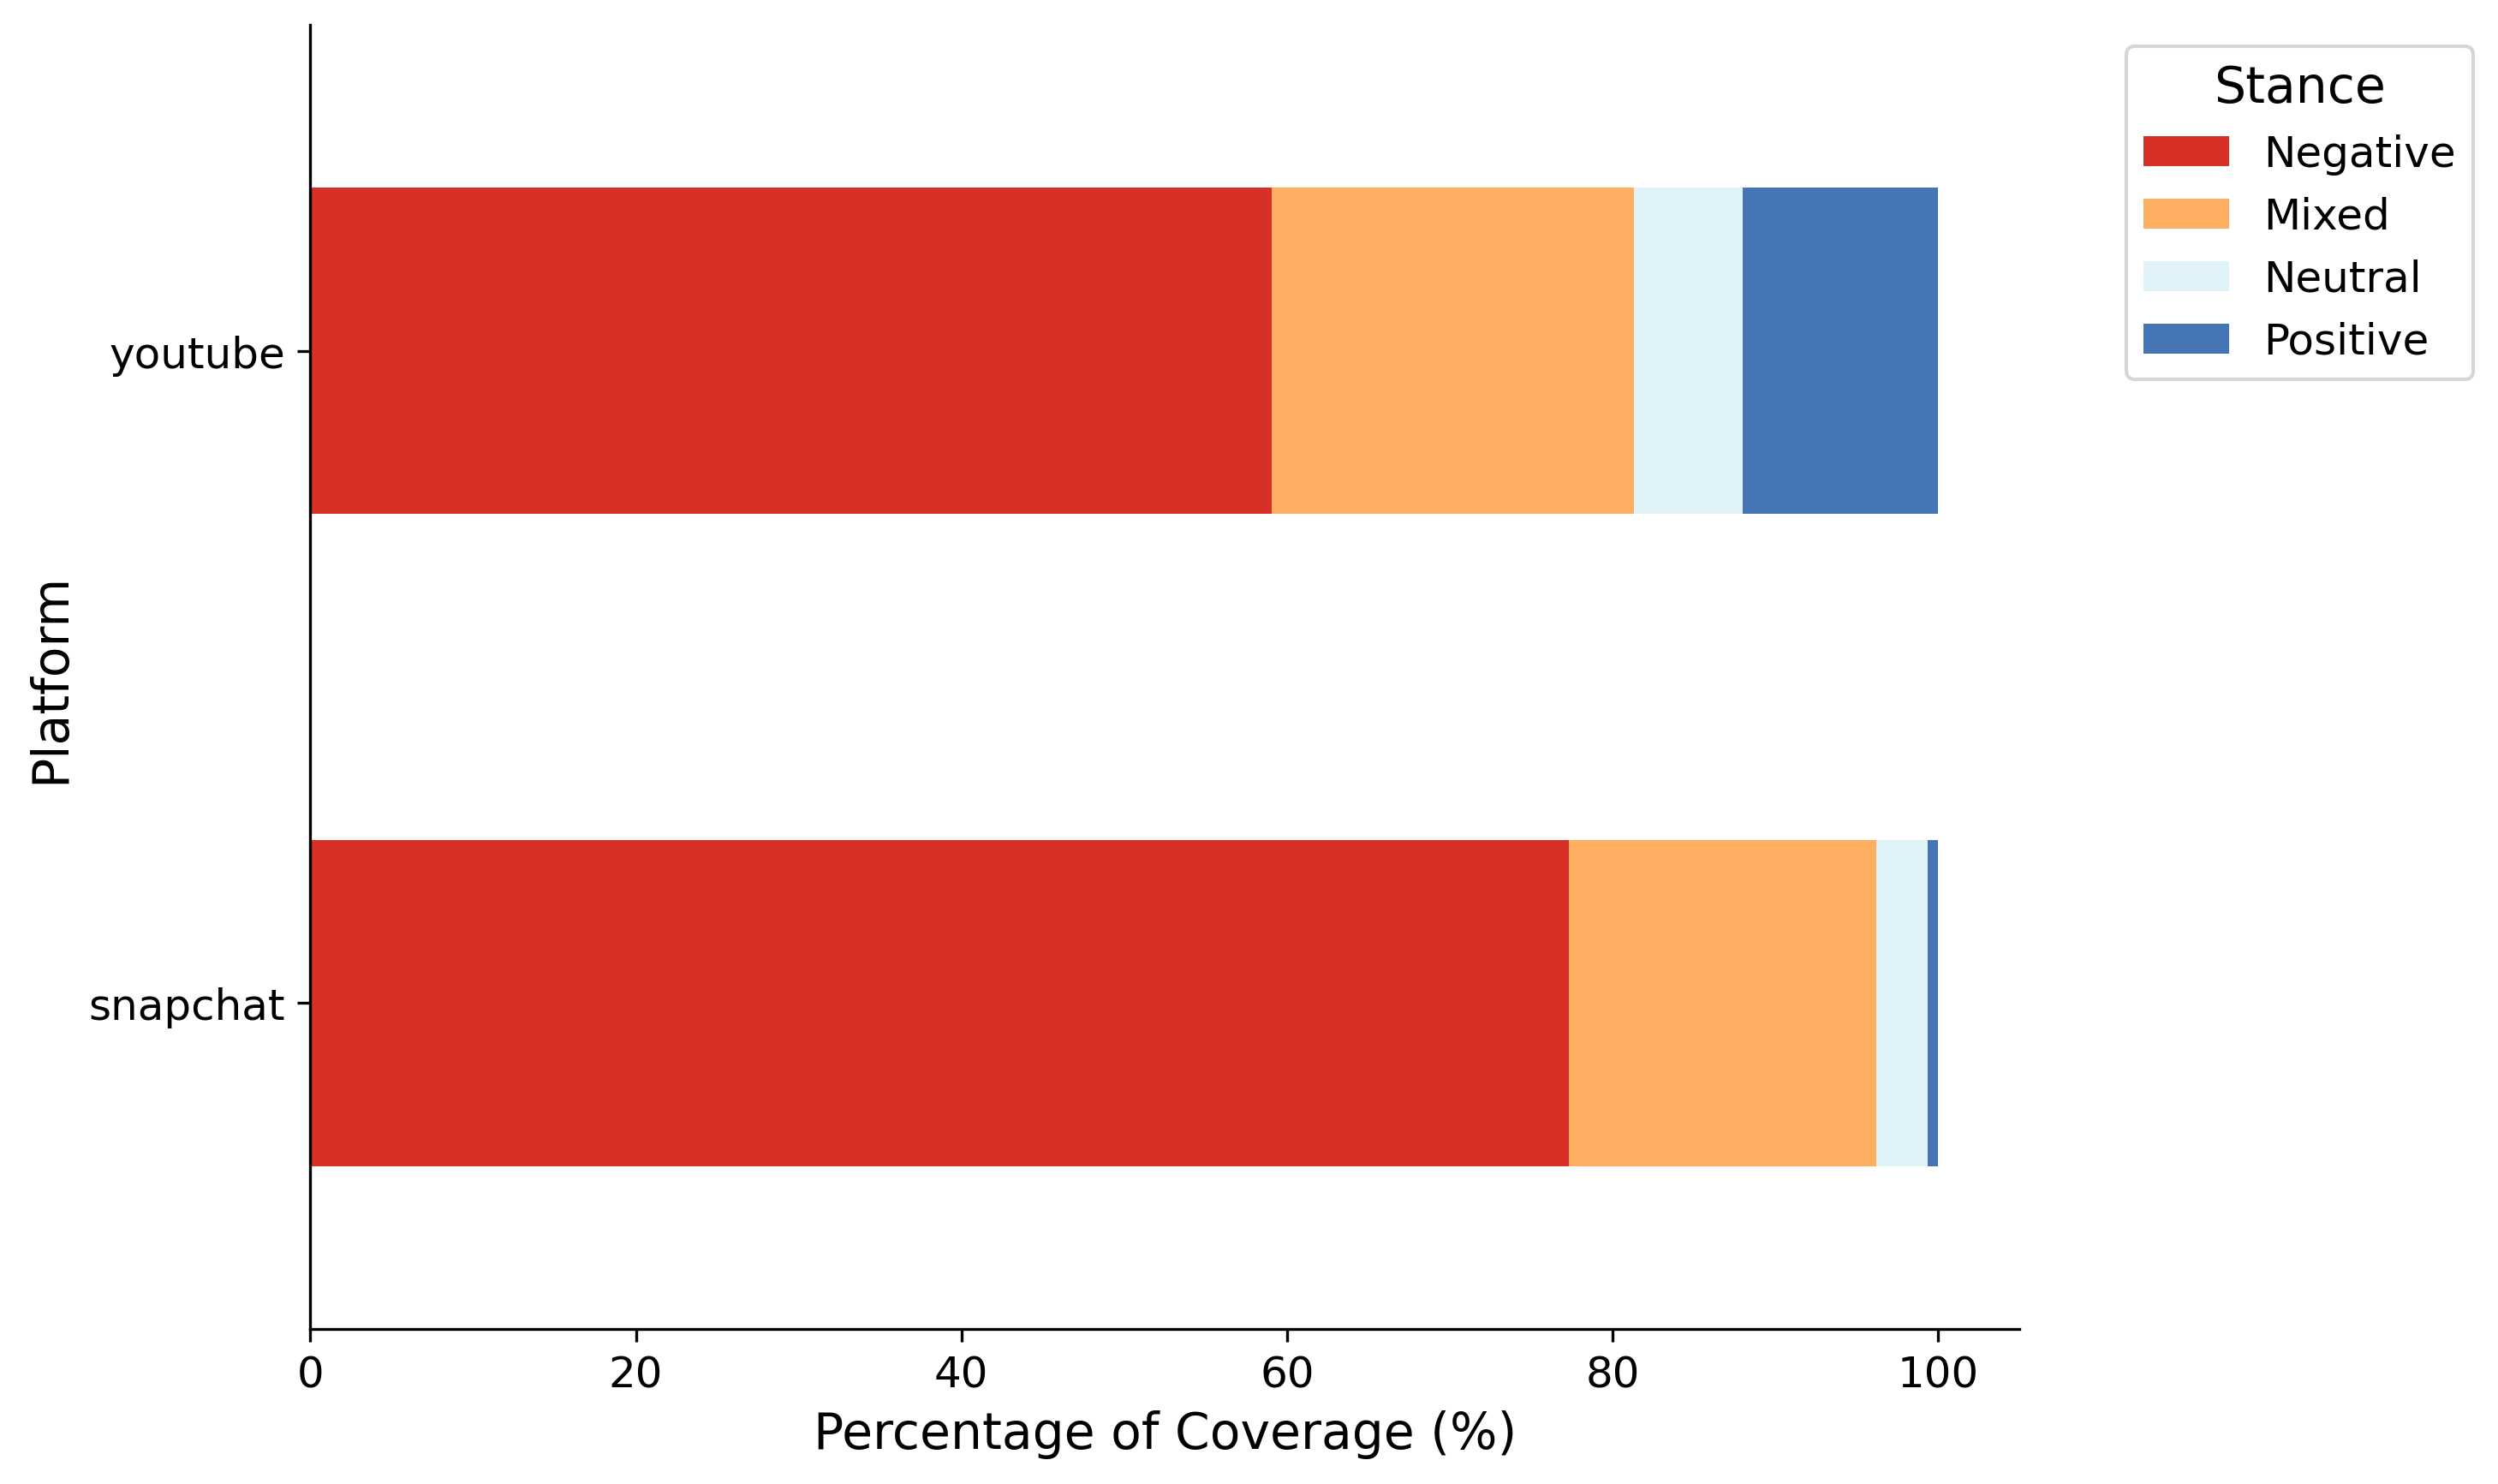

--- INSIGHT 1: PLATFORM RISK PROFILES ---
final_label Negative  Mixed Neutral Positive
platform                                    
snapchat       77.3%  18.9%    3.1%     0.6%
youtube        59.0%  22.3%    6.7%    12.0%




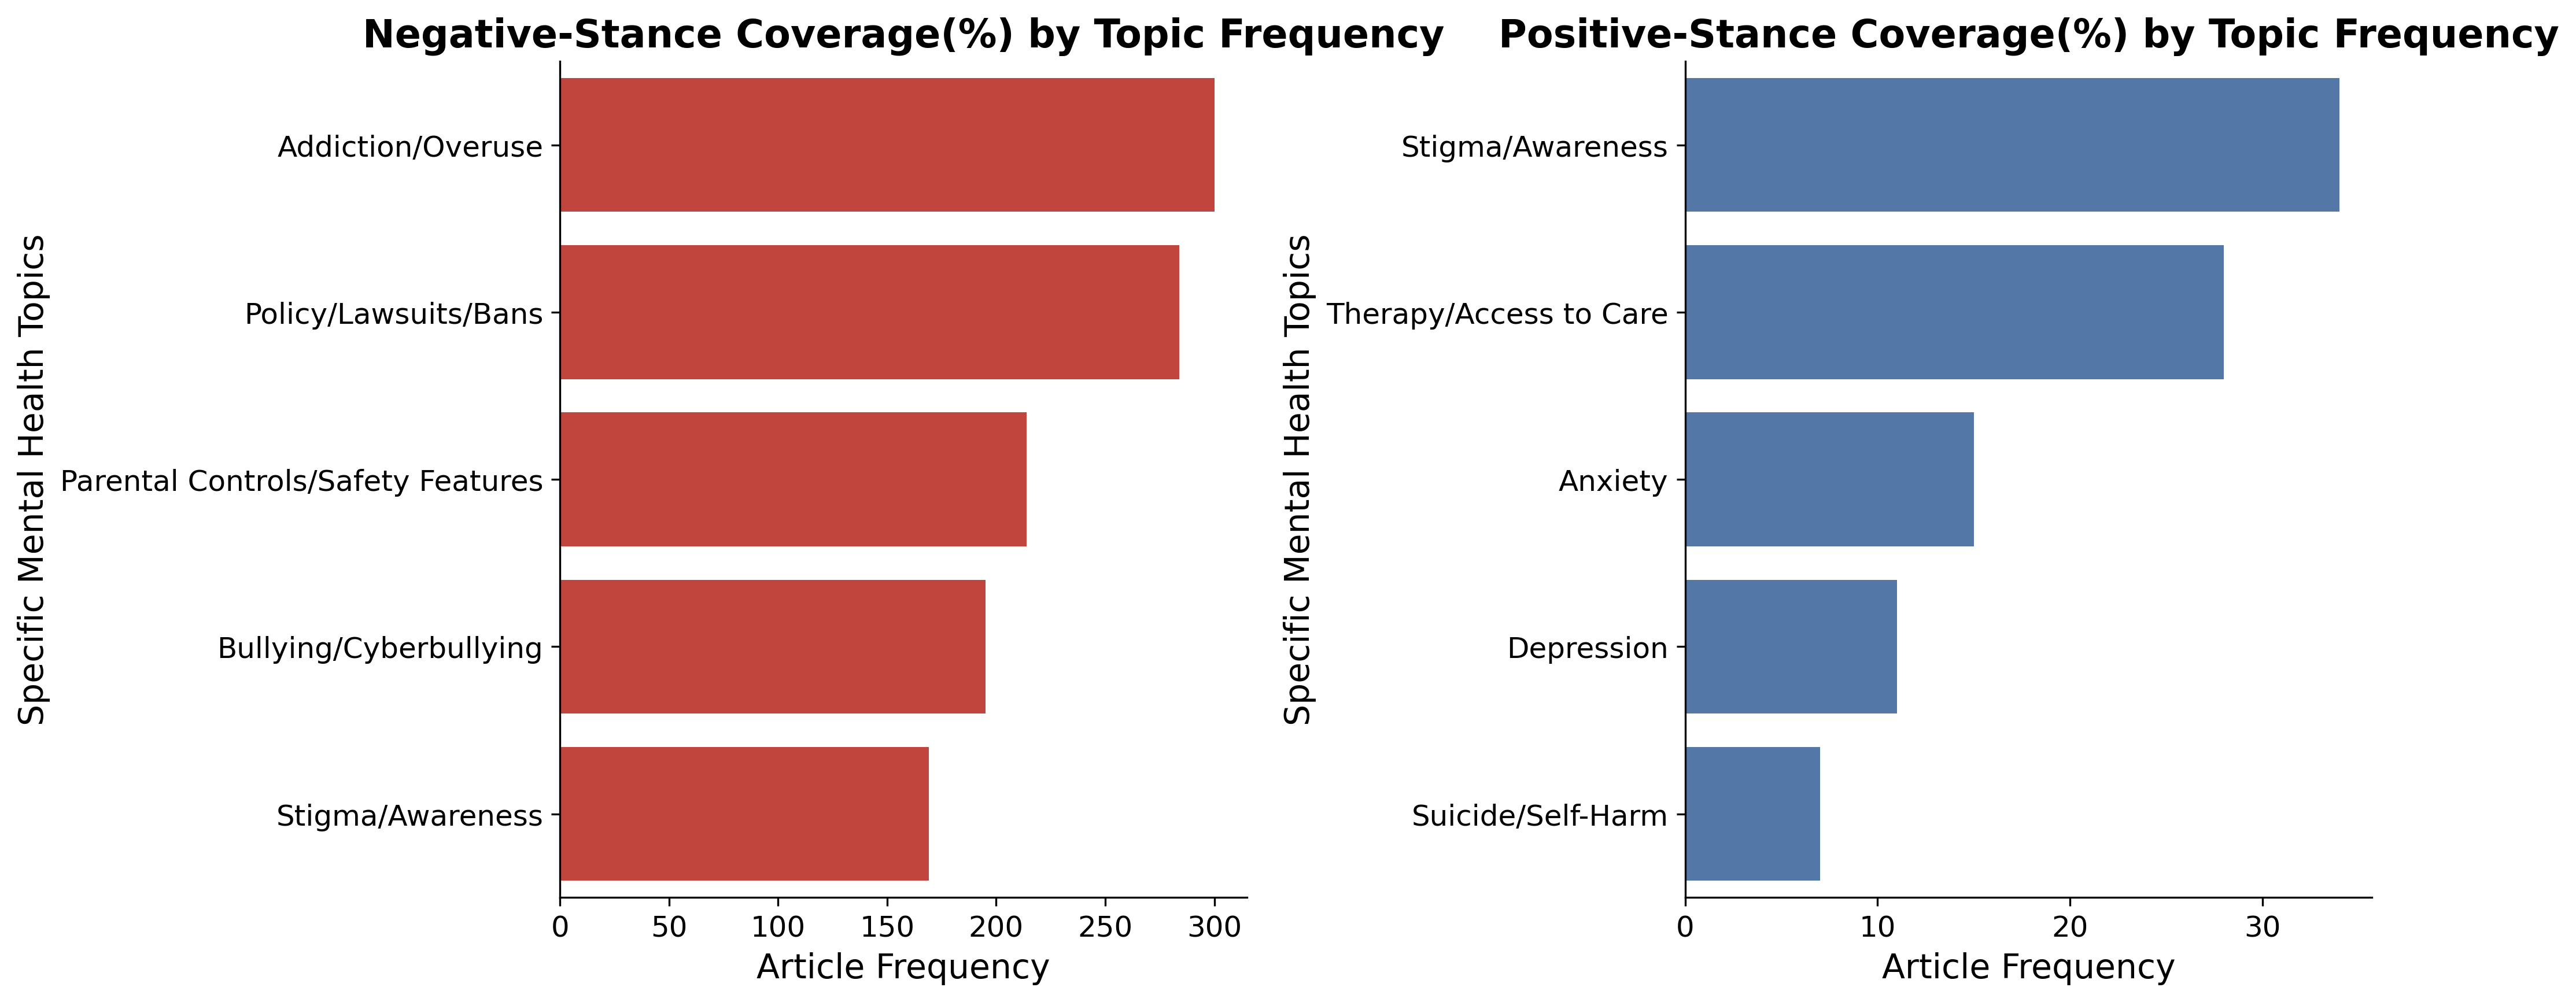

--- INSIGHT 2: Dominant Topics by Stance ---
Top Negative Topics: ['Addiction/Overuse', 'Policy/Lawsuits/Bans', 'Parental Controls/Safety Features']
Top Positive Topics: ['Stigma/Awareness', 'Therapy/Access to Care', 'Anxiety']


--- INSIGHT 3: TOPIC CO-OCCURRENCES ---
- Addiction/Overuse & Policy/Lawsuits/Bans: 303 times
- Addiction/Overuse & Parental Controls/Safety Features: 252 times
- Parental Controls/Safety Features & Policy/Lawsuits/Bans: 250 times
- Addiction/Overuse & Stigma/Awareness: 230 times
- Bullying/Cyberbullying & Policy/Lawsuits/Bans: 207 times
- Addiction/Overuse & Bullying/Cyberbullying: 201 times
- Policy/Lawsuits/Bans & Stigma/Awareness: 201 times
- Bullying/Cyberbullying & Parental Controls/Safety Features: 160 times
- Parental Controls/Safety Features & Stigma/Awareness: 159 times
- Bullying/Cyberbullying & Stigma/Awareness: 136 times


--- INSIGHT 4: CONSENSUS DISTRIBUTIONS ---
Consensus data not available.


In [ ]:

# Sociological EDA & Visualizations

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from itertools import combinations
from pathlib import Path

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False
})

try:
    path_clean = FINAL_DS_DIR / "FINAL_ACCEPTED_CLEAN_CLAUDE.csv"
    path_all = FINAL_DS_DIR / "FINAL_ACCEPTED_ALL_CLAUDE.csv"
except NameError:
    path_clean = "FINAL_ACCEPTED_CLEAN_CLAUDE.csv"
    path_all = "FINAL_ACCEPTED_ALL_CLAUDE.csv"

df_clean = pd.read_csv(path_clean)
df_all = pd.read_csv(path_all)

print("Data Loaded Successfully! Generating Insights...\n")

# 1st insight for Platform stance distributions

crosstab_platform = pd.crosstab(df_clean['platform'], df_clean['final_label'], normalize='index') * 100
cols = ['Negative', 'Mixed', 'Neutral', 'Positive']
crosstab_platform = crosstab_platform.reindex(columns=[c for c in cols if c in crosstab_platform.columns])

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d73027', '#fdae61', '#e0f3f8', '#4575b4']
crosstab_platform.plot(kind='barh', stacked=True, color=colors, ax=ax)

ax.set_xlabel('Percentage of Coverage (%)')
ax.set_ylabel('Platform')
plt.legend(title='Stance', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Fig1_Platform_Stance.png')
plt.show()

print("1st Insight: platform risk profiles")
print(crosstab_platform.round(1).astype(str) + '%')
print("\n")


# 2nd insight for thematic drivers
def get_topic_counts(df_subset):
    all_topics = []
    for t_str in df_subset['final_topics'].dropna():
        if str(t_str).strip() and str(t_str) != 'nan':
            topics = [t.strip() for t in str(t_str).split(',')]
            all_topics.extend(topics)
    return Counter(all_topics)

df_neg = df_clean[df_clean['final_label'] == 'Negative']
df_pos = df_clean[df_clean['final_label'] == 'Positive']

neg_counts = pd.Series(get_topic_counts(df_neg)).sort_values(ascending=False).head(5)
pos_counts = pd.Series(get_topic_counts(df_pos)).sort_values(ascending=False).head(5)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x=neg_counts.values, y=neg_counts.index, ax=axes[0], color='#d73027')
axes[0].set_xlabel('Article Frequency')
axes[0].set_ylabel('Specific Mental Health Topics')
axes[0].set_title('Negative-Stance Coverage(%) by Topic Frequency', fontweight='bold')

sns.barplot(x=pos_counts.values, y=pos_counts.index, ax=axes[1], color='#4575b4')
axes[1].set_xlabel('Article Frequency')
axes[1].set_ylabel('Specific Mental Health Topics')
axes[1].set_title('Positive-Stance Coverage(%) by Topic Frequency', fontweight='bold')

plt.tight_layout()
plt.savefig('Fig2_Thematic_Drivers.png')
plt.show()

print(" 2nd Insight: Dominant Topics by Stance")
print("Top Negative Topics:", neg_counts.index.tolist()[:3])
print("Top Positive Topics:", pos_counts.index.tolist()[:3])
print("\n")


# 3rd insight: topic co-occurrence
co_occurrences = Counter()
for t_str in df_clean['final_topics'].dropna():
    if str(t_str).strip() and str(t_str) != 'nan':
        topics = [t.strip() for t in str(t_str).split(',')]
        if len(topics) > 1:
            for combo in combinations(sorted(topics), 2):
                co_occurrences[combo] += 1

top_pairs = co_occurrences.most_common(10)

print("3rd insight: topic co-occurrences")
for pair, count in top_pairs:
    print(f"- {pair[0]} & {pair[1]}: {count} times")
print("\n")


# 4th and Final insight: consensus distribution
print("4th insight: consensus distributions")
if 'consensus_status' in df_all.columns:
    consensus_counts = df_all['consensus_status'].value_counts()
    for status, count in consensus_counts.items():
        print(f"- {status}: {count} ({count/len(df_all)*100:.1f}%)")
else:
    print("Consensus data is not available.")

In [ ]:

# Predictive Baselines (LR & SVM)
import pandas as pd
import numpy as np
import os
import pickle
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report

try:
    path_clean = FINAL_DS_DIR / "FINAL_ACCEPTED_CLEAN_CLAUDE.csv"
except NameError:
    path_clean = "FINAL_ACCEPTED_CLEAN_CLAUDE.csv"

df_clean = pd.read_csv(path_clean)
df_clean['full_text'] = df_clean['full_text'].fillna("")
df_clean = df_clean[df_clean['full_text'].str.strip() != ""]

X = df_clean['full_text']
y = df_clean['final_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=87, stratify=y
)

vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

def print_evaluation_metrics(model_name, y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    labels = ['Negative', 'Positive', 'Neutral', 'Mixed']
    print(f"\n {model_name} Performance ")
    header = f"{'Model':<6} | "
    for label in labels:
        header += f"{label[:3]} (P R F1) | "
    header += "Overall (P R F1)"
    print(header)
    print("-" * len(header))
    row = f"{model_name:<6} | "
    for label in labels:
        if label in report:
            p, r, f = report[label]['precision'], report[label]['recall'], report[label]['f1-score']
            row += f"{p:.2f} {r:.2f} {f:.2f} | "
        else:
            row += "0.00 0.00 0.00 | "
    op, orc, of1 = report['macro avg']['precision'], report['macro avg']['recall'], report['macro avg']['f1-score']
    row += f"{op:.2f} {orc:.2f} {of1:.2f}"
    print(row)

CACHE_FILE_8 = "/content/drive/MyDrive/NLP_Research_Project/outputs/cache_cell8_ml.pkl"

if os.path.exists(CACHE_FILE_8):
    print(f" Loading Cached ML Predictions")
    with open(CACHE_FILE_8, 'rb') as f:
        lr_preds, svm_preds = pickle.load(f)
    print_evaluation_metrics("LR", y_test, lr_preds)
    print_evaluation_metrics("SVM", y_test, svm_preds)
else:
    print("Traditional ML Prediction Results")
    models = {
        "LR": LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
        "SVM": SVC(kernel='linear', class_weight='balanced', random_state=42)
    }
    lr_preds, svm_preds = None, None
    for name, model in models.items():
        model.fit(X_train_vec, y_train)
        preds = model.predict(X_test_vec)
        print_evaluation_metrics(name, y_test, preds)
        if name == "LR": lr_preds = preds
        if name == "SVM": svm_preds = preds

    with open(CACHE_FILE_8, 'wb') as f:
        pickle.dump((lr_preds, svm_preds), f)

========== TRADITIONAL ML PREDICTION RESULTS ==========

--- LR Performance ---
Model  | Neg (P R F1) | Pos (P R F1) | Neu (P R F1) | Mix (P R F1) | Overall (P R F1)
-------------------------------------------------------------------------------------
LR     | 0.97 0.88 0.92 | 0.78 0.91 0.84 | 0.83 0.87 0.85 | 0.70 0.86 0.77 | 0.82 0.88 0.85

--- SVM Performance ---
Model  | Neg (P R F1) | Pos (P R F1) | Neu (P R F1) | Mix (P R F1) | Overall (P R F1)
-------------------------------------------------------------------------------------
SVM    | 0.97 0.89 0.93 | 0.88 0.72 0.79 | 0.91 0.87 0.89 | 0.67 0.88 0.76 | 0.86 0.84 0.84

>>> Saved ML predictions to /content/drive/MyDrive/NLP_Research_Project/outputs/cache_cell8_ml.pkl to survive session timeouts.


In [ ]:
# Predictive Baselines (RoBERTa)

import torch
import os
import pickle
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import evaluate
import numpy as np
from sklearn.metrics import classification_report

label_mapping = {"Negative": 0, "Positive": 1, "Neutral": 2, "Mixed": 3}
reverse_mapping = {v: k for k, v in label_mapping.items()}
y_true_labels = [reverse_mapping[l] for l in y_test.map(label_mapping).tolist()]

CACHE_FILE_9 = "/content/drive/MyDrive/NLP_Research_Project/outputs/cache_cell9_roberta.pkl"

# We can reuse the print function defined in Cell 8

if os.path.exists(CACHE_FILE_9):
    print("Loading Cached RoBERTa Predictions...")
    with open(CACHE_FILE_9, 'rb') as f:
        roberta_preds = pickle.load(f)
    print_evaluation_metrics("RoBERTa", y_true_labels, roberta_preds)
else:
    print("RoBERTa Fine-Tuning")
    train_df = pd.DataFrame({'text': X_train, 'label': y_train.map(label_mapping)})
    test_df = pd.DataFrame({'text': X_test, 'label': y_test.map(label_mapping)})
    train_dataset = Dataset.from_pandas(train_df)
    test_dataset = Dataset.from_pandas(test_df)

    model_name = "roberta-base"
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    def tokenize_func(examples):
        return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=512)

    tokenized_train = train_dataset.map(tokenize_func, batched=True)
    tokenized_test = test_dataset.map(tokenize_func, batched=True)

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=4)
    metric = evaluate.load("accuracy")

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=-1)
        return {"accuracy": metric.compute(predictions=predictions, references=labels)["accuracy"]}

    training_args = TrainingArguments(
        output_dir="./results", learning_rate=2e-5, per_device_train_batch_size=8,
        per_device_eval_batch_size=8, num_train_epochs=3, weight_decay=0.01,
        eval_strategy="epoch", logging_dir='./logs',
    )

    trainer = Trainer(
        model=model, args=training_args, train_dataset=tokenized_train,
        eval_dataset=tokenized_test, compute_metrics=compute_metrics,
    )

    print("Training RoBERTa...")
    trainer.train()

    print("\nEvaluating RoBERTa...")
    predictions = trainer.predict(tokenized_test)
    preds = np.argmax(predictions.predictions, axis=-1)
    roberta_preds = [reverse_mapping[p] for p in preds]

    print_evaluation_metrics("RoBERTa", y_true_labels, roberta_preds)

    with open(CACHE_FILE_9, 'wb') as f:
        pickle.dump(roberta_preds, f)
    print(f"\n>>> Successfully saved RoBERTa predictions to {CACHE_FILE_9}!")

========== RoBERTa FINE-TUNING ==========


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

Training RoBERTa...


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.440362,0.857143
2,No log,0.374078,0.879464
3,No log,0.383106,0.886161


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Evaluating RoBERTa...



--- RoBERTa Performance ---
Model  | Neg (P R F1) | Pos (P R F1) | Neu (P R F1) | Mix (P R F1) | Overall (P R F1)
-------------------------------------------------------------------------------------
RoBERTa | 0.93 0.95 0.94 | 0.82 0.84 0.83 | 0.90 0.78 0.84 | 0.77 0.73 0.75 | 0.85 0.83 0.84

>>> Saved RoBERTa predictions to /content/drive/MyDrive/NLP_Research_Project/outputs/cache_cell9_roberta.pkl.


In [ ]:

# Advanced Transformer Baselines

import torch
import pandas as pd
import numpy as np
import os
import pickle
import gc
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

CACHE_FILE_10 = "/content/drive/MyDrive/NLP_Research_Project/outputs/cache_cell10_adv_transformers.pkl"

if os.path.exists(CACHE_FILE_10):
    print("Loading Cached Advanced Transformer redictions...")
    with open(CACHE_FILE_10, 'rb') as f:
        advanced_preds = pickle.load(f)
    for model_key, preds in advanced_preds.items():
        print_evaluation_metrics(model_key, y_true_labels, preds)

    social_roberta_preds = advanced_preds.get("Social-RoBERTa")
    deberta_preds = advanced_preds.get("DeBERTa-v3")
    longformer_preds = advanced_preds.get("Longformer")
else:
    print("Advanced Transformer Fine-Tuning")
    train_df = pd.DataFrame({'text': X_train, 'label': y_train.map(label_mapping)})
    test_df = pd.DataFrame({'text': X_test, 'label': y_test.map(label_mapping)})
    train_dataset = Dataset.from_pandas(train_df)
    test_dataset = Dataset.from_pandas(test_df)

    advanced_models = {
        "Social-RoBERTa": "cardiffnlp/twitter-roberta-base",
        "DeBERTa-v3": "microsoft/deberta-v3-base",
        "Longformer": "allenai/longformer-base-4096"
    }

    advanced_preds = {}

    for model_key, hf_repo in advanced_models.items():
        print(f"\n\n>>> INITIALIZING: {model_key} <<<")
        tokenizer = AutoTokenizer.from_pretrained(hf_repo)
        max_len = 1024 if "longformer" in model_key.lower() else 512

        def tokenize_func(examples):
            return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=max_len)

        tokenized_train = train_dataset.map(tokenize_func, batched=True)
        tokenized_test = test_dataset.map(tokenize_func, batched=True)

        model = AutoModelForSequenceClassification.from_pretrained(hf_repo, num_labels=4)

        training_args = TrainingArguments(
            output_dir=f"./results_{model_key}", learning_rate=2e-5, per_device_train_batch_size=4,
            per_device_eval_batch_size=4, num_train_epochs=3, weight_decay=0.01,
            eval_strategy="epoch", logging_dir=f'./logs_{model_key}', save_strategy="no"
        )

        trainer = Trainer(
            model=model, args=training_args, train_dataset=tokenized_train,
            eval_dataset=tokenized_test, compute_metrics=compute_metrics,
        )

        print(f"Training {model_key}...")
        trainer.train()

        print(f"Evaluating {model_key}...")
        predictions = trainer.predict(tokenized_test)
        preds = np.argmax(predictions.predictions, axis=-1)
        current_preds = [reverse_mapping[p] for p in preds]

        # Save into dict so they don't overwrite each other!
        advanced_preds[model_key] = current_preds

        print_evaluation_metrics(model_key, y_true_labels, current_preds)

        del model, trainer, tokenized_train, tokenized_test
        torch.cuda.empty_cache()
        gc.collect()

    # Unpack for global scope
    social_roberta_preds = advanced_preds.get("Social-RoBERTa")
    deberta_preds = advanced_preds.get("DeBERTa-v3")
    longformer_preds = advanced_preds.get("Longformer")

    with open(CACHE_FILE_10, 'wb') as f:
        pickle.dump(advanced_preds, f)
    print(f"\n>>> Saved all Advanced Transformer predictions to {CACHE_FILE_10}.")

========== ADVANCED TRANSFORMER FINE-TUNING ==========


>>> INITIALIZING: Social-RoBERTa <<<


config.json:   0%|          | 0.00/565 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

Map:   0%|          | 0/1044 [00:00<?, ? examples/s]

...

Training Longformer...


model.safetensors:   0%|          | 0.00/597M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.519930,0.857143
2,0.518423,0.468596,0.892857
3,0.518423,0.476833,0.888393


Evaluating Longformer...



--- Longformer Performance ---
Model  | Neg (P R F1) | Pos (P R F1) | Neu (P R F1) | Mix (P R F1) | Overall (P R F1)
-------------------------------------------------------------------------------------
Longformer | 0.92 0.96 0.94 | 0.93 0.78 0.85 | 0.86 0.83 0.84 | 0.78 0.72 0.75 | 0.87 0.82 0.84

>>> Saved all Advanced Transformer predictions to /content/drive/MyDrive/NLP_Research_Project/outputs/cache_cell10_adv_transformers.pkl.


In [ ]:
# Zero-Shot LLM Predictions (On 30% Test Set)

import pandas as pd
import time
import json
import re
import os
import pickle
from tqdm import tqdm
from sklearn.metrics import classification_report
from openai import OpenAI
import anthropic

CACHE_FILE_11 = "/content/drive/MyDrive/NLP_Research_Project/outputs/cache_cell11_llm_test.pkl"

if os.path.exists(CACHE_FILE_11):
    print("loading cached zero-shot LLM (test set)...)
    with open(CACHE_FILE_11, 'rb') as f:
        gpt_test_preds, claude_test_preds = pickle.load(f)
    print_evaluation_metrics("GPT-4o-Mini", list(y_test), gpt_test_preds)
    print_evaluation_metrics("Claude-Sonnet", list(y_test), claude_test_preds)
else:
    print("Zero-Shot LLMs")
    print(f"Evaluating LLMs on the {len(X_test)} Test Set articles...")

    try:
        client_openai = OpenAI(api_key=OPENAI_KEY)
        client_claude = anthropic.Anthropic(api_key=CLAUDE_KEY)
    except NameError:
        print("API Keys not found in environment.")

    STANCE_PROMPT = """
    You are a research annotator analyzing news coverage of social media.
    Determine the STANCE regarding the platform's impact on mental health.
    - Positive: Benefits, support, community, helpful features.
    - Negative: Harms, addiction, bullying, lawsuits, decline in well-being.
    - Neutral: Factual business news or balanced reporting.
    - Mixed: Significant elements of both harm and benefit.

    Return ONLY a valid JSON object: {"label": "Positive/Negative/Neutral/Mixed"}
    """

    def extract_label_from_response(text):
        try:
            match = re.search(r'\{[^{}]*\"label\"[^{}]*\}', text, re.IGNORECASE)
            if match:
                data = json.loads(match.group(0))
                label = data.get("label", "Error").strip().title()
                if label in ['Positive', 'Negative', 'Neutral', 'Mixed']:
                    return label
        except Exception:
            pass
        return "Neutral"

    def get_gpt_pred(text):
        try:
            response = client_openai.chat.completions.create(
                model="gpt-4o-mini",
                messages=[{"role": "user", "content": STANCE_PROMPT + f"\n\nARTICLE:\n{text[:4000]}"}],
                temperature=0.0
            )
            return extract_label_from_response(response.choices[0].message.content)
        except:
            return "Neutral"

    def get_claude_pred(text):
        try:
            response = client_claude.messages.create(
                model="claude-sonnet-4-6",
                max_tokens=50,
                temperature=0.0,
                messages=[{"role": "user", "content": STANCE_PROMPT + f"\n\nARTICLE:\n{text[:4000]}"}]
            )
            return extract_label_from_response(response.content[0].text)
        except:
            return "Neutral"

    gpt_test_preds = []
    claude_test_preds = []

    for text in tqdm(X_test, desc="Evaluating LLMs on Test Set"):
        gpt_test_preds.append(get_gpt_pred(text))
        claude_test_preds.append(get_claude_pred(text))
        time.sleep(0.1)

    print_evaluation_metrics("GPT-4o-Mini", list(y_test), gpt_test_preds)
    print_evaluation_metrics("Claude-Sonnet", list(y_test), claude_test_preds)

    with open(CACHE_FILE_11, 'wb') as f:
        pickle.dump((gpt_test_preds, claude_test_preds), f)
    print(f"\n>>> Successfully saved Test Set LLM predictions to {CACHE_FILE_11}.")

========== ZERO-SHOT LLMs ON 30% TEST SET ==========
Evaluating LLMs on the 448 Test Set articles...


Evaluating LLMs on Test Set: 100%|██████████| 448/448 [27:27<00:00,  3.68s/it]


--- GPT-4o-Mini Performance ---
Model  | Neg (P R F1) | Pos (P R F1) | Neu (P R F1) | Mix (P R F1) | Overall (P R F1)
-------------------------------------------------------------------------------------
GPT-4o-Mini | 0.93 0.78 0.85 | 0.80 1.00 0.89 | 0.52 0.70 0.59 | 0.57 0.77 0.65 | 0.70 0.81 0.75

--- Claude-Sonnet Performance ---
Model  | Neg (P R F1) | Pos (P R F1) | Neu (P R F1) | Mix (P R F1) | Overall (P R F1)
-------------------------------------------------------------------------------------
Claude-Sonnet | 0.95 0.93 0.94 | 0.91 0.94 0.92 | 0.39 0.83 0.53 | 0.89 0.68 0.77 | 0.78 0.84 0.79

>>> Saved Test Set LLM predictions to /content/drive/MyDrive/NLP_Research_Project/outputs/cache_cell11_llm_test.pkl.


In [ ]:

# Zero-Shot LLM Predictions (Full Set)

import pandas as pd
import time
import json
import re
import os
import pickle
from tqdm import tqdm
from sklearn.metrics import classification_report
from openai import OpenAI
import anthropic

CACHE_FILE_12 = "/content/drive/MyDrive/NLP_Research_Project/outputs/cache_cell12_llm_full.pkl"

X_full = df_clean['full_text'].tolist()
y_full_true = df_clean['final_label'].tolist()

if os.path.exists(CACHE_FILE_12):
    print(" Loading Cached Zero-Shot LLM (Full Set)..")
    with open(CACHE_FILE_12, 'rb') as f:
        gpt_preds, claude_preds = pickle.load(f)
    print_evaluation_metrics("GPT-4o", y_full_true, gpt_preds)
    print_evaluation_metrics("Claude-Sonnet", y_full_true, claude_preds)
else:
    print("Zero-shot LLM Evaluation")
    print(f"Evaluating on dataset containing {len(df_clean)} records...")

    try:
        client_openai = OpenAI(api_key=OPENAI_KEY)
        client_claude = anthropic.Anthropic(api_key=CLAUDE_KEY)
    except NameError:
        print("API Keys not found in environment.")

    STANCE_PROMPT = """
    You are a research annotator analyzing news coverage of social media.
    Determine the STANCE regarding the platform's impact on mental health.
    - Positive: Benefits, support, community, helpful features.
    - Negative: Harms, addiction, bullying, lawsuits, decline in well-being.
    - Neutral: Factual business news or balanced reporting.
    - Mixed: Significant elements of both harm and benefit.

    Return ONLY a valid JSON object: {"label": "Positive/Negative/Neutral/Mixed"}
    """

    def extract_label_from_response(text):
        try:
            match = re.search(r'\{[^{}]*\"label\"[^{}]*\}', text, re.IGNORECASE)
            if match:
                data = json.loads(match.group(0))
                label = data.get("label", "Error").strip().title()
                if label in ['Positive', 'Negative', 'Neutral', 'Mixed']:
                    return label
        except Exception:
            pass
        return "Neutral"

    def get_gpt_pred(text):
        try:
            response = client_openai.chat.completions.create(
                model="gpt-4o",
                messages=[{"role": "user", "content": STANCE_PROMPT + f"\n\nARTICLE:\n{text[:4000]}"}],
                temperature=0.0
            )
            return extract_label_from_response(response.choices[0].message.content)
        except:
            return "Neutral"

    def get_claude_pred(text):
        try:
            response = client_claude.messages.create(
                model="claude-sonnet-4-6",
                max_tokens=50,
                temperature=0.0,
                messages=[{"role": "user", "content": STANCE_PROMPT + f"\n\nARTICLE:\n{text[:4000]}"}]
            )
            return extract_label_from_response(response.content[0].text)
        except:
            return "Neutral"

    gpt_preds = []
    claude_preds = []

    for text in tqdm(X_full, desc="Evaluating LLMs"):
        gpt_preds.append(get_gpt_pred(text))
        claude_preds.append(get_claude_pred(text))
        time.sleep(0.1)

    print_evaluation_metrics("GPT-4o", y_full_true, gpt_preds)
    print_evaluation_metrics("Claude-Sonnet", y_full_true, claude_preds)

    with open(CACHE_FILE_12, 'wb') as f:
        pickle.dump((gpt_preds, claude_preds), f)
    print(f"\n>>> Saved Full Set LLM predictions to {CACHE_FILE_12}.")

========== ZERO-SHOT LLM EVALUATION ==========
Evaluating on dataset containing 1492 records...


Evaluating LLMs: 100%|██████████| 1492/1492 [1:11:38<00:00,  2.88s/it]


--- GPT-4o Performance ---
Model  | Neg (P R F1) | Pos (P R F1) | Neu (P R F1) | Mix (P R F1) | Overall (P R F1)
-------------------------------------------------------------------------------------
GPT-4o | 0.89 0.98 0.93 | 0.89 0.87 0.88 | 0.54 0.87 0.67 | 0.98 0.52 0.68 | 0.83 0.81 0.79

--- Claude-Sonnet Performance ---
Model  | Neg (P R F1) | Pos (P R F1) | Neu (P R F1) | Mix (P R F1) | Overall (P R F1)
-------------------------------------------------------------------------------------
Claude-Sonnet | 0.95 0.92 0.94 | 0.85 0.87 0.86 | 0.36 0.74 0.49 | 0.89 0.72 0.79 | 0.76 0.81 0.77

>>> Saved Full Set LLM predictions to /content/drive/MyDrive/NLP_Research_Project/outputs/cache_cell12_llm_full.pkl.


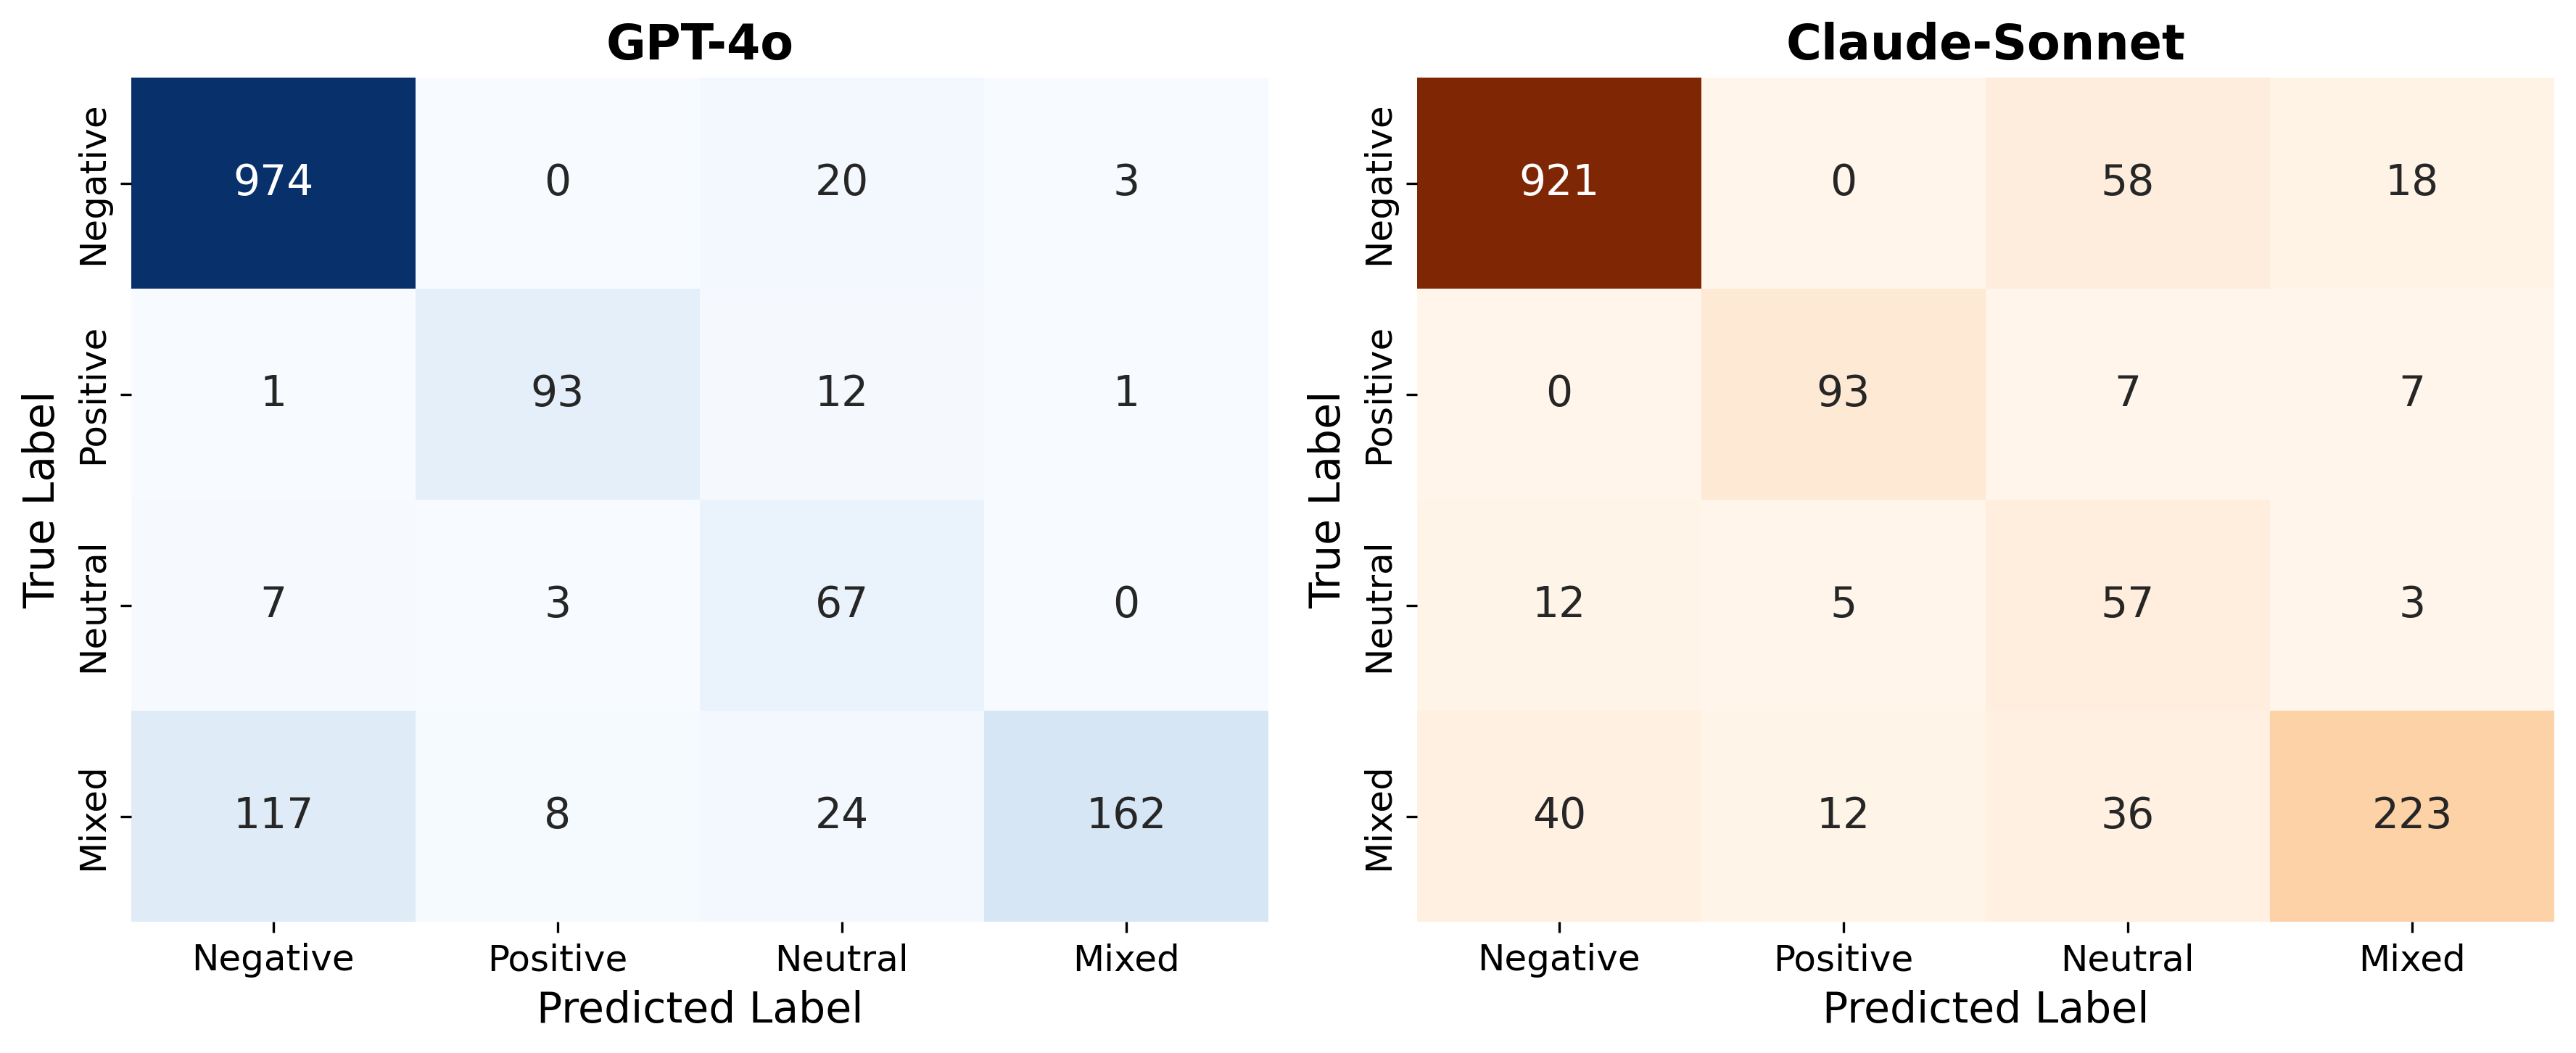

In [ ]:
# Confusion Matrices- LLMs

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

plt.rcParams.update({'figure.dpi': 300, 'font.size': 12})
labels = ['Negative', 'Positive', 'Neutral', 'Mixed']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. GPT-4o
cm_gpt = confusion_matrix(y_full_true, gpt_preds, labels=labels)
sns.heatmap(cm_gpt, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels,
            ax=axes[0], cbar=False, annot_kws={"size": 14})
axes[0].set_title('GPT-4o', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# 2. Claude-Sonnet
cm_claude = confusion_matrix(y_full_true, claude_preds, labels=labels)
sns.heatmap(cm_claude, annot=True, fmt='d', cmap='Oranges', xticklabels=labels, yticklabels=labels,
            ax=axes[1], cbar=False, annot_kws={"size": 14})
axes[1].set_title('Claude-Sonnet', fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.savefig('confusion_matrices_llm.png', bbox_inches='tight')
plt.show()

In [ ]:

# Platform-specific metrics for LLMs

from sklearn.metrics import classification_report
import numpy as np

# Creating masks to separate YouTube & Snapchat articles
yt_mask = df_clean['platform'] == 'youtube'
snap_mask = df_clean['platform'] == 'snapchat'

def print_platform_breakdown(model_name, y_true, y_pred, mask, platform_name):
    # Filtering the true and predicted labels based on the platform mask
    y_true_sub = np.array(y_true)[mask]
    y_pred_sub = np.array(y_pred)[mask]

    report = classification_report(y_true_sub, y_pred_sub, output_dict=True, zero_division=0)

    print(f"\n--- {model_name} | {platform_name.upper()} ---")
    labels = ['Negative', 'Positive', 'Neutral', 'Mixed']


    row = f"{model_name} ({platform_name[:4]}) | "
    for label in labels:
        if label in report:
            row += f"{report[label]['precision']:.4f} {report[label]['recall']:.4f} {report[label]['f1-score']:.4f} | "
        else:
            row += "0.0000 0.0000 0.0000 | "

    row += f"{report['macro avg']['precision']:.4f} {report['macro avg']['recall']:.4f} {report['macro avg']['f1-score']:.4f}"
    print(row)

print("Platform Breakdown")
print("Format: Model (Plat) | Neg (P R F1) | Pos (P R F1) | Neu (P R F1) | Mix (P R F1) | Macro (P R F1)")
print_platform_breakdown("GPT-4o", y_full_true, gpt_preds, yt_mask, "YouTube")
print_platform_breakdown("GPT-4o", y_full_true, gpt_preds, snap_mask, "Snapchat")
print_platform_breakdown("Claude-Sonnet", y_full_true, claude_preds, yt_mask, "YouTube")
print_platform_breakdown("Claude-Sonnet", y_full_true, claude_preds, snap_mask, "Snapchat")

===== PLATFORM BREAKDOWN FOR TABLE IV (Full Dataset) =====
Format: Model (Plat) | Neg (P R F1) | Pos (P R F1) | Neu (P R F1) | Mix (P R F1) | Macro (P R F1)

--- GPT-4o | YOUTUBE ---
GPT-4o (YouT) | 0.8630 0.9585 0.9082 | 0.8900 0.8641 0.8768 | 0.4811 0.8947 0.6258 | 0.9663 0.4503 0.6143 | 0.8001 0.7919 0.7563

--- GPT-4o | SNAPCHAT ---
GPT-4o (Snap) | 0.9106 0.9959 0.9514 | 1.0000 1.0000 1.0000 | 0.9412 0.8000 0.8649 | 0.9870 0.6333 0.7716 | 0.9597 0.8573 0.8970

--- Claude-Sonnet | YOUTUBE ---
Claude-Sonnet (YouT) | 0.9454 0.8557 0.8983 | 0.8426 0.8835 0.8626 | 0.3056 0.7719 0.4378 | 0.8503 0.6545 0.7396 | 0.7360 0.7914 0.7346

--- Claude-Sonnet | SNAPCHAT ---
Claude-Sonnet (Snap) | 0.9476 0.9939 0.9702 | 1.0000 0.5000 0.6667 | 0.9286 0.6500 0.7647 | 0.9423 0.8167 0.8750 | 0.9546 0.7401 0.8191


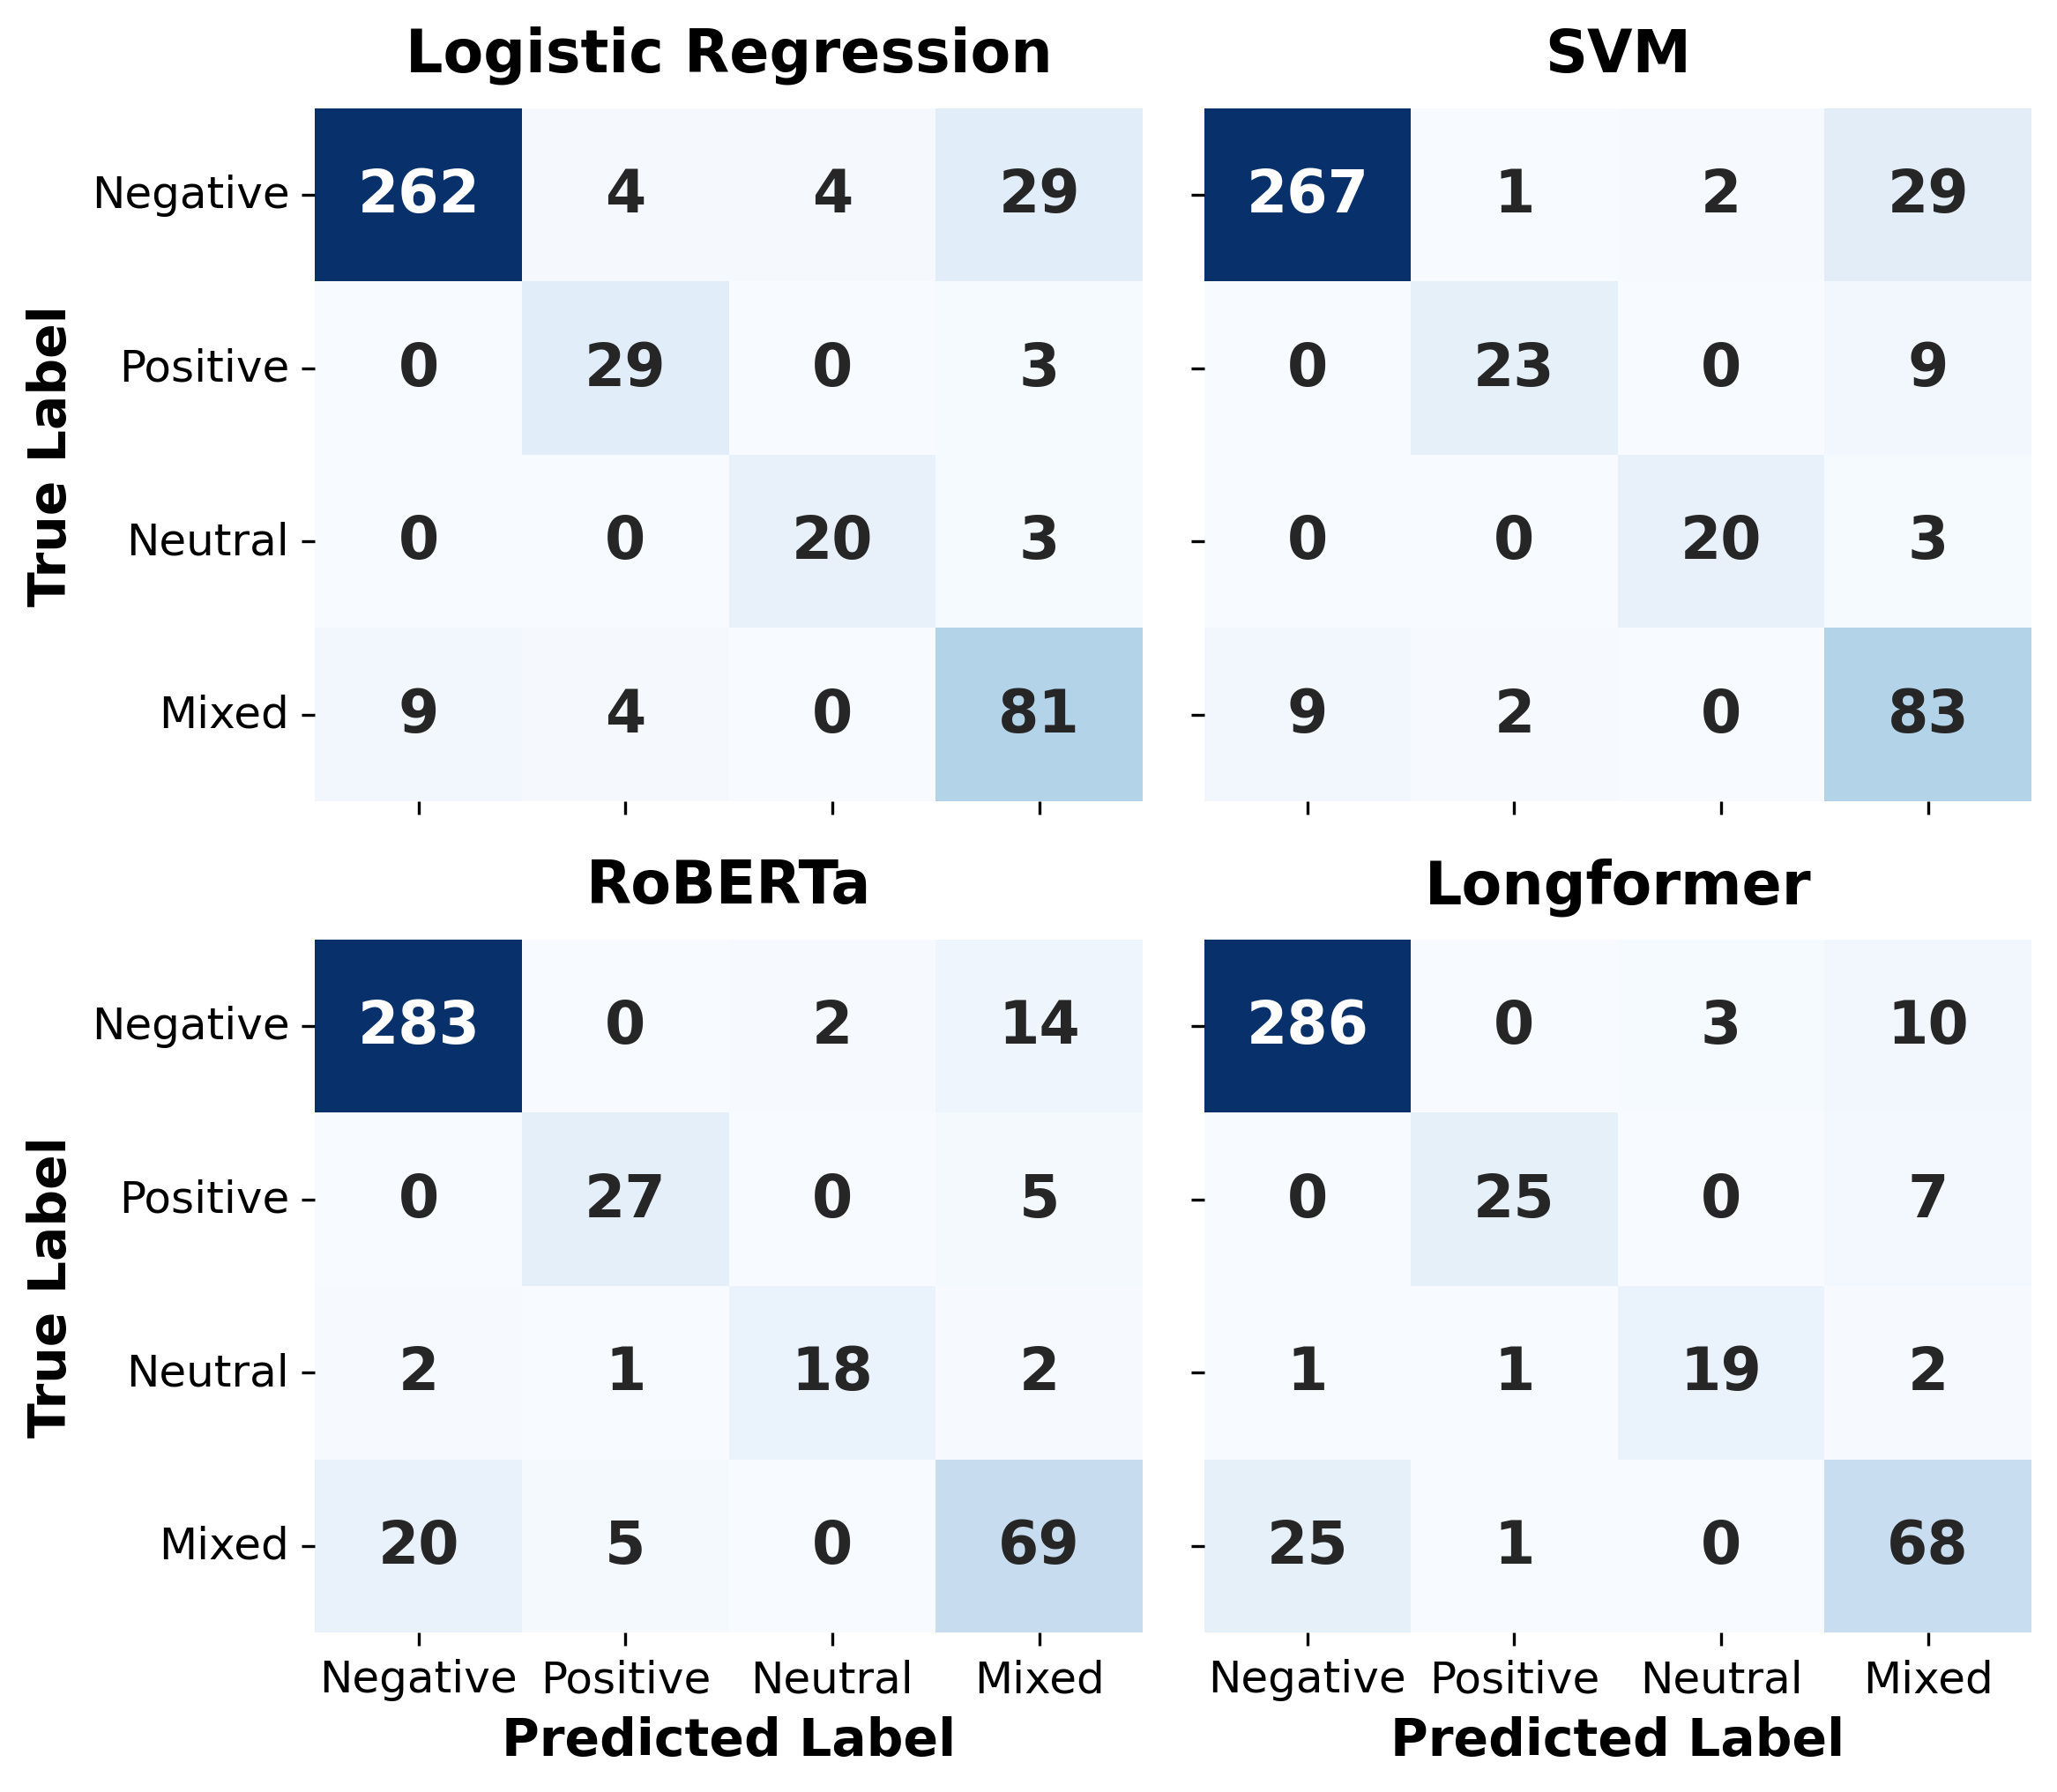

In [ ]:
# Confusion Matrices - Supervised Models

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np


plt.rcParams.update({'figure.dpi': 300, 'font.size': 14, 'axes.titlesize': 16, 'axes.labelsize': 14})
labels = ['Negative', 'Positive', 'Neutral', 'Mixed']

fig, axes = plt.subplots(2, 2, figsize=(8, 7))

uniform_cmap = 'Blues'

def plot_cm(ax, preds, title):
    if preds is not None:
        cm = confusion_matrix(y_test, preds, labels=labels)
        sns.heatmap(cm, annot=True, fmt='d', cmap=uniform_cmap, xticklabels=labels, yticklabels=labels,
                    ax=ax, cbar=False, annot_kws={"size": 16, "weight": "bold"})
    else:
        ax.text(0.5, 0.5, 'Data Missing', ha='center', va='center', fontsize=14)
    ax.set_title(title, fontweight='bold', pad=10)

# Logistic Regression
plot_cm(axes[0, 0], globals().get('lr_preds'), 'Logistic Regression')
axes[0, 0].set_ylabel('True Label', fontweight='bold')
axes[0, 0].set_xticklabels([])

# SVM
plot_cm(axes[0, 1], globals().get('svm_preds'), 'SVM')
axes[0, 1].set_xticklabels([])
axes[0, 1].set_yticklabels([])

# RoBERTa
plot_cm(axes[1, 0], globals().get('roberta_preds'), 'RoBERTa')
axes[1, 0].set_xlabel('Predicted Label', fontweight='bold')
axes[1, 0].set_ylabel('True Label', fontweight='bold')

# Longformer
plot_cm(axes[1, 1], globals().get('longformer_preds'), 'Longformer')
axes[1, 1].set_xlabel('Predicted Label', fontweight='bold')
axes[1, 1].set_yticklabels([])

plt.tight_layout()
plt.savefig('confusion_matrices_blue.png', bbox_inches='tight')
plt.show()